DATASET LOADED SUCCESSFULLY

First 5 Rows
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  

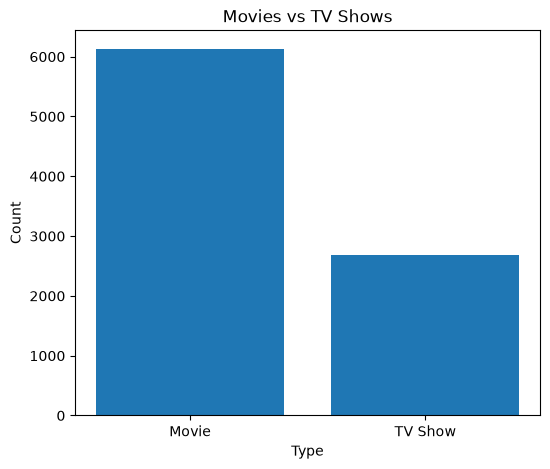

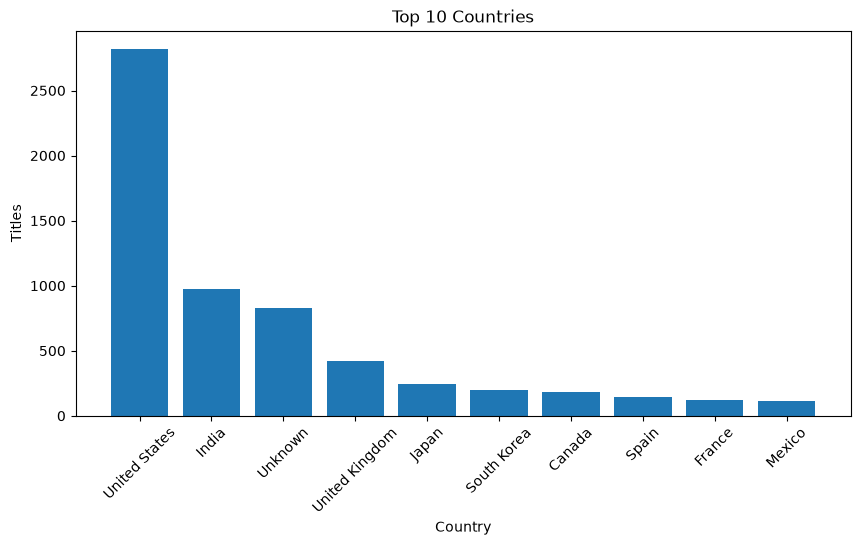

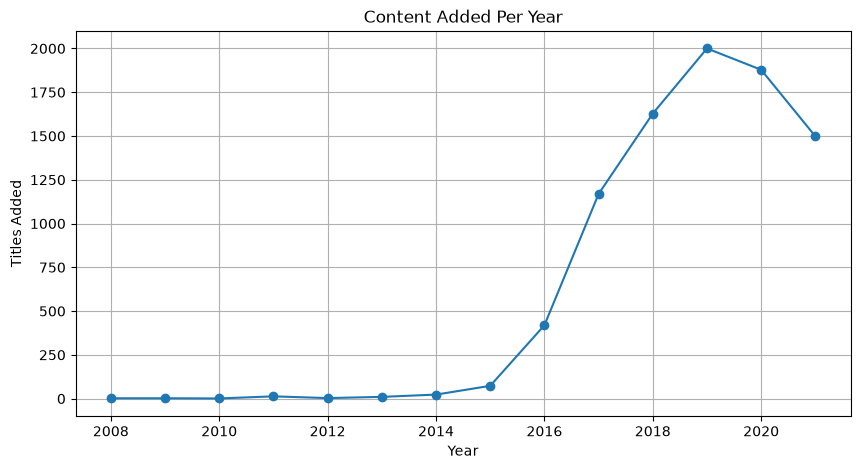

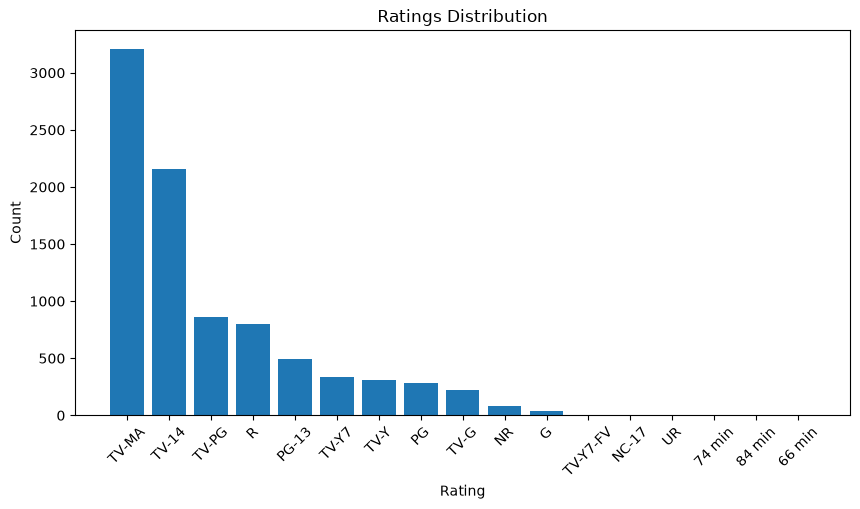

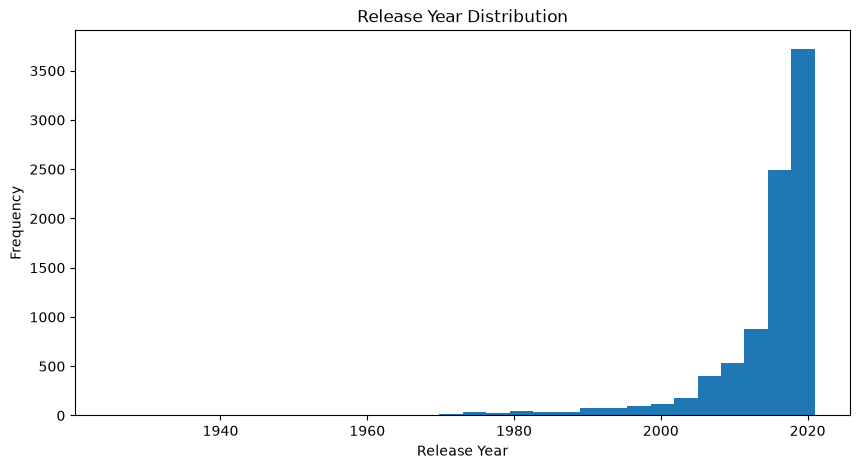

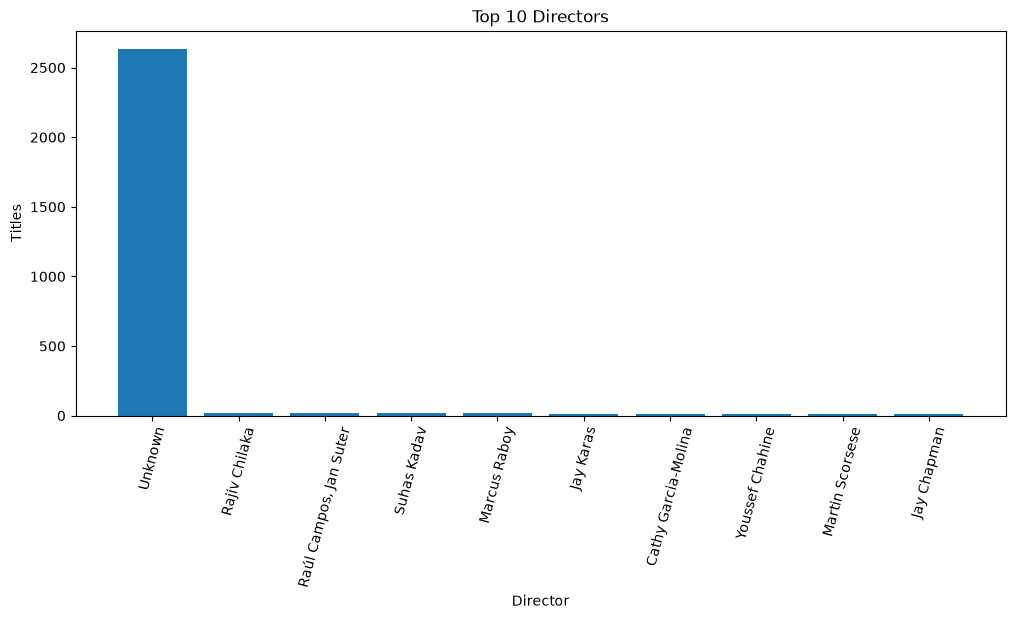

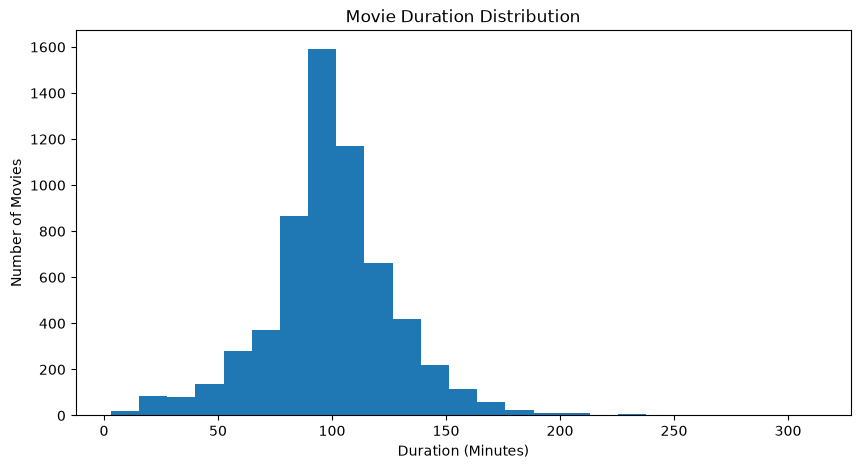

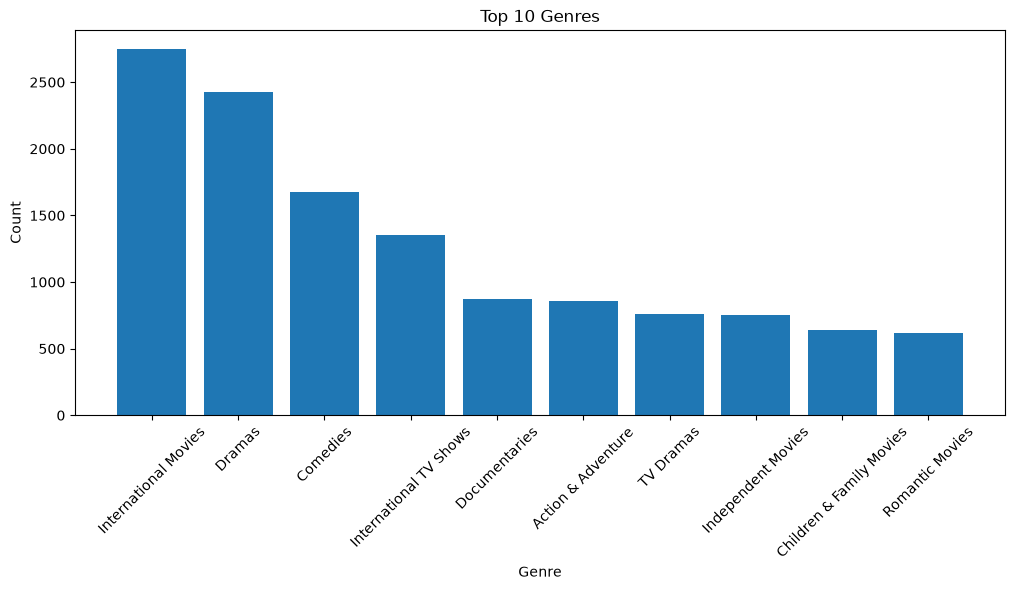


FINAL DATASET INFORMATION
Shape : (8807, 13)

Remaining Missing Values
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      88
release_year     0
rating           0
duration         3
listed_in        0
description      0
year_added      88
dtype: int64

First 10 Rows
  show_id     type                             title  \
0      s1    Movie              Dick Johnson Is Dead   
1      s2  TV Show                     Blood & Water   
2      s3  TV Show                         Ganglands   
3      s4  TV Show             Jailbirds New Orleans   
4      s5  TV Show                      Kota Factory   
5      s6  TV Show                     Midnight Mass   
6      s7    Movie  My Little Pony: A New Generation   
7      s8    Movie                           Sankofa   
8      s9  TV Show     The Great British Baking Show   
9     s10    Movie                      The Starling   

                        director  \


In [4]:
# ==========================================================
# NETFLIX DATA PREPROCESSING & VISUALIZATION
# Compatible with Python 3.14 + Pandas 3.x
# ==========================================================

# -----------------------------
# Import Libraries
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# -----------------------------
# Load Dataset
# -----------------------------

file_name = "netflix_titles(1).csv"

if not os.path.exists(file_name):
    print("Dataset not found!")
    print("Current Folder:", os.getcwd())
    print("Files:", os.listdir())
    raise FileNotFoundError(file_name)

df = pd.read_csv(file_name)

print("="*60)
print("DATASET LOADED SUCCESSFULLY")
print("="*60)

# -----------------------------
# Display Dataset
# -----------------------------

print("\nFirst 5 Rows")
print(df.head())

print("\nLast 5 Rows")
print(df.tail())

print("\nShape")
print(df.shape)

print("\nColumns")
print(df.columns)

print("\nDataset Info")
print(df.info())

print("\nStatistical Summary")
print(df.describe(include="all"))

# -----------------------------
# Missing Values
# -----------------------------

print("\nMissing Values")
print(df.isnull().sum())

# -----------------------------
# Duplicate Values
# -----------------------------

print("\nDuplicate Rows :", df.duplicated().sum())

df = df.drop_duplicates()

# -----------------------------
# Fill Missing Values
# -----------------------------

df["director"] = df["director"].fillna("Unknown")

df["cast"] = df["cast"].fillna("Not Available")

df["country"] = df["country"].fillna("Unknown")

df["rating"] = df["rating"].fillna(df["rating"].mode().iloc[0])

# Forward Fill (Pandas 3.x)
df["date_added"] = df["date_added"].ffill()

# Convert Date
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

print("\nMissing Values After Cleaning")
print(df.isnull().sum())

# -----------------------------
# Data Types
# -----------------------------

print("\nData Types")
print(df.dtypes)

# -----------------------------
# NumPy Operations
# -----------------------------

print("\n==============================")
print("NUMPY OPERATIONS")
print("==============================")

print("Total Missing Values :", np.sum(df.isna().sum()))
print("Average Release Year :", np.mean(df["release_year"]))
print("Median Release Year :", np.median(df["release_year"]))
print("Minimum Release Year :", np.min(df["release_year"]))
print("Maximum Release Year :", np.max(df["release_year"]))

# -----------------------------
# Save Cleaned Dataset
# -----------------------------

df.to_csv("netflix_cleaned.csv", index=False)

print("\nCleaned Dataset Saved Successfully")

# ==========================================================
# VISUALIZATION 1
# Movies vs TV Shows
# ==========================================================

type_count = df["type"].value_counts()

plt.figure(figsize=(6,5))
plt.bar(type_count.index, type_count.values)
plt.title("Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

# ==========================================================
# VISUALIZATION 2
# Top 10 Countries
# ==========================================================

country = df["country"].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(country.index, country.values)
plt.xticks(rotation=45)
plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Titles")
plt.show()

# ==========================================================
# VISUALIZATION 3
# Content Added Per Year
# ==========================================================

df["year_added"] = df["date_added"].dt.year

year = df["year_added"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(year.index, year.values, marker="o")
plt.title("Content Added Per Year")
plt.xlabel("Year")
plt.ylabel("Titles Added")
plt.grid(True)
plt.show()

# ==========================================================
# VISUALIZATION 4
# Ratings Distribution
# ==========================================================

rating = df["rating"].value_counts()

plt.figure(figsize=(10,5))
plt.bar(rating.index, rating.values)
plt.xticks(rotation=45)
plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# ==========================================================
# VISUALIZATION 5
# Release Year Distribution
# ==========================================================

plt.figure(figsize=(10,5))
plt.hist(df["release_year"], bins=30)
plt.title("Release Year Distribution")
plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.show()

# ==========================================================
# VISUALIZATION 6
# Top 10 Directors
# ==========================================================

director = df["director"].value_counts().head(10)

plt.figure(figsize=(12,5))
plt.bar(director.index, director.values)
plt.xticks(rotation=75)
plt.title("Top 10 Directors")
plt.xlabel("Director")
plt.ylabel("Titles")
plt.show()

# ==========================================================
# VISUALIZATION 7
# Movie Duration Distribution
# ==========================================================

movies = df[df["type"] == "Movie"].copy()

movies["duration"] = movies["duration"].str.replace(" min", "", regex=False)

movies["duration"] = pd.to_numeric(movies["duration"], errors="coerce")

plt.figure(figsize=(10,5))
plt.hist(movies["duration"].dropna(), bins=25)
plt.title("Movie Duration Distribution")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")
plt.show()

# ==========================================================
# VISUALIZATION 8
# Top 10 Genres
# ==========================================================

genres = df["listed_in"].str.split(", ").explode()

top_genres = genres.value_counts().head(10)

plt.figure(figsize=(12,5))
plt.bar(top_genres.index, top_genres.values)
plt.xticks(rotation=45)
plt.title("Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

# ==========================================================
# FINAL OUTPUT
# ==========================================================

print("\n==============================")
print("FINAL DATASET INFORMATION")
print("==============================")

print("Shape :", df.shape)

print("\nRemaining Missing Values")
print(df.isnull().sum())

print("\nFirst 10 Rows")
print(df.head(10))

print("\nNetflix Data Preprocessing & Visualization Completed Successfully!")